In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn folium requests

In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import folium

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
url = "https://api.spacexdata.com/v4/launches"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df = df[['name','date_utc','success','rocket','launchpad']]
df.head()

,name,date_utc,success,rocket,launchpad
0,FalconSat,2006-03-24T22:30:00.000Z,False,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86
1,DemoSat,2007-03-21T01:10:00.000Z,False,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86
2,Trailblazer,2008-08-03T03:34:00.000Z,False,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86
3,RatSat,2008-09-28T23:15:00.000Z,True,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86
4,RazakSat,2009-07-13T03:35:00.000Z,True,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86


In [4]:
df = df.dropna()

df['success'] = df['success'].astype(int)

df['year'] = pd.to_datetime(df['date_utc']).dt.year

df.head()

,name,date_utc,success,rocket,launchpad,year
0,FalconSat,2006-03-24T22:30:00.000Z,0,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,2006
1,DemoSat,2007-03-21T01:10:00.000Z,0,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,2007
2,Trailblazer,2008-08-03T03:34:00.000Z,0,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,2008
3,RatSat,2008-09-28T23:15:00.000Z,1,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,2008
4,RazakSat,2009-07-13T03:35:00.000Z,1,5e9d0d95eda69955f709d1eb,5e9e4502f5090995de566f86,2009


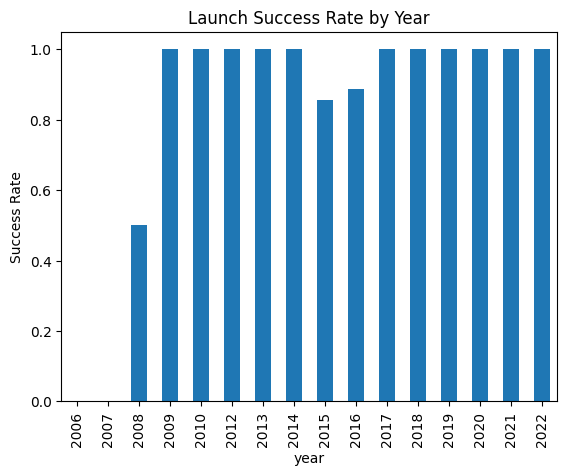

In [5]:
success_by_year = df.groupby('year')['success'].mean()

plt.figure()
success_by_year.plot(kind='bar')
plt.title("Launch Success Rate by Year")
plt.ylabel("Success Rate")

plt.savefig("success_by_year.png")
plt.show()

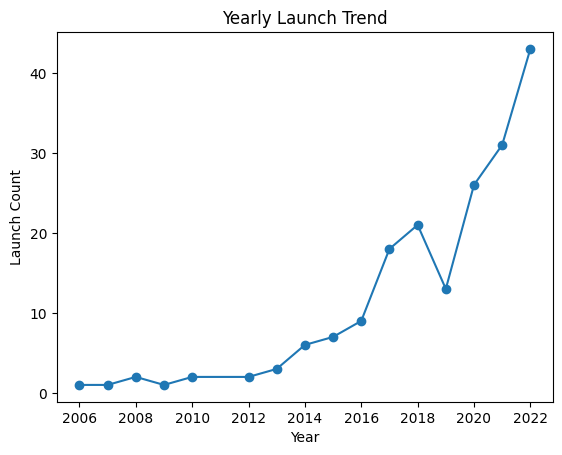

In [6]:
launch_counts = df['year'].value_counts().sort_index()

plt.figure()
launch_counts.plot(kind='line', marker='o')

plt.title("Yearly Launch Trend")
plt.xlabel("Year")
plt.ylabel("Launch Count")

plt.savefig("launch_trend.png")
plt.show()

In [7]:
launch_sites = {
"KSC LC-39A":[28.573255,-80.646895],
"CCAFS SLC-40":[28.561857,-80.577366],
"VAFB SLC-4E":[34.632834,-120.610746]
}

m = folium.Map(location=[28,-80], zoom_start=4)

for site,coord in launch_sites.items():
    folium.Marker(coord,popup=site).add_to(m)

m.save("launch_sites_map.html")
m

In [8]:
X = df[['year']]
y = df['success']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test,pred)

print("Model Accuracy:",accuracy)

Model Accuracy: 0.9210526315789473


In [9]:
cm = confusion_matrix(y_test,pred)

print(cm)

[[ 0  3]
 [ 0 35]]


In [10]:
df.to_csv("processed_spacex_data.csv")